# Notebook 07 — Preprocessing (Phase A): DEM → minibacias

**Goal:** turn the corrected-domain DEM into the model's spatial units (**minibacias**), in pure Python — no QGIS.

**How to read this notebook.** Every step has the same three parts:
1. *What* it does (plain language),
2. *Which parameter(s)* it uses and *why* the choice,
3. Code + a **map with a legend/colour-bar** (never a bare colour gradient).

Stack: `pyflwdir` (flow routing & delineation) + `rasterio` (rasters) + `matplotlib` (maps).

## Parameters — the 4 knobs (edit these, everything else follows)

| Parameter | What it controls | If you increase it | Recommended |
|-----------|------------------|--------------------|-------------|
| `SCALE` | DEM down-sampling (speed vs detail). `1` = full 90 m, `8` ≈ 720 m | faster but coarser boundaries | `1` for the final run, `8` to preview |
| `STREAM_THR` | drainage area (km²) needed to **start a river** | fewer, larger rivers | `200` km² (tune) |
| `N_TARGET` | **desired number of minibacias** (area_min = basin_area / N_TARGET) | more, smaller minibacias | `12000` (mean ≈ 21 km²) |
| `OUTLET` | (lon, lat) of the basin outlet gauge (Calamar) | — | Calamar `(-74.915, 10.243)` |

Nothing else needs editing — the rest of the notebook derives from these four.

## How each value is chosen — justification (not arbitrary)

Two kinds of parameters: **technical** (set by convergence) and **physical / data-constrained** (set against a control).

- **`SCALE` — technical.** No physical value. Prototype at `8` for speed; the final product is **`SCALE=1`** (90 m).
  *Verify by convergence:* halve SCALE until the basin area and the minibacia count stop changing.
- **`STREAM_THR` — matched to the real river network.** Too low ⇒ fake channels on hillslopes; too high ⇒ missing
  tributaries. *Choose & check by:* (1) overlaying the extracted streams on a reference network (HydroSHEDS / OSM /
  IDEAM) and taking the value where the mainstem + major tributaries appear without hillslope noise; (2) making sure
  **every IDEAM gauge sits on a stream**; (3) a realistic drainage density (~0.5–2 km/km²). Start: 200 km².
- **`N_TARGET` — set by gauge separation (binding), heterogeneity, runtime.** The decisive test (**Step 6**): each of
  the 167 discharge gauges must land on a **distinct** minibacia. Choose N, run the collision test, raise N while
  collisions remain. Keep mean area ~10–50 km² and runtime reasonable ⇒ `N_TARGET = 12000`.
- **`OUTLET` — a known location, not a knob.** Calamar, the official outlet gauge (Restrepo's reference); coordinates
  from IDEAM. *Verify:* the delineated area must match ~257,000 km² (we got 257,808 ✓, Step 4).

In [1]:
import os, glob, tarfile, tempfile
from pathlib import Path
import numpy as np, pandas as pd, rasterio
from rasterio.enums import Resampling
from affine import Affine
from matplotlib.colors import LogNorm, ListedColormap
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import pyflwdir
%matplotlib inline

# ======================= PARAMETERS =======================
SCALE      = 8                 # DEM down-sampling: 1 = full 90 m (final), 8 = fast preview
STREAM_THR = 100               # km^2 of upstream area to start a river channel
N_TARGET   = 12000              # target number of minibacias (mean area = basin_area / N_TARGET)
OUTLET     = (-74.915, 10.243) # (lon, lat) of Calamar, the basin outlet gauge
# ==========================================================

# locate repo + the corrected DEM (extract the .tif from the tar once)
REPO=None
for b in [Path.cwd()]+list(Path.cwd().parents):
    if (b/'data'/'raw'/'dem').exists(): REPO=b; break
REPO=REPO or Path.cwd()
tar=sorted(glob.glob(str(REPO/'data'/'raw'/'dem'/'rasters_COP90*Corr*.tar.gz')))
work=Path(tempfile.gettempdir())/'output_hh.tif'
if tar and not work.exists():
    with tarfile.open(tar[0]) as t: t.extract('output_hh.tif', path=work.parent)
DEM=str(work if work.exists() else '/tmp/output_hh.tif')
print('DEM :', DEM)
print(f'Parameters -> SCALE={SCALE}  STREAM_THR={STREAM_THR} km2  N_TARGET={N_TARGET}  OUTLET={OUTLET}')

DEM : /sessions/epic-sleepy-mendel/tmp/output_hh.tif
Parameters -> SCALE=8  STREAM_THR=100 km2  N_TARGET=12000  OUTLET=(-74.915, 10.243)


## Step 1 — Load the DEM, fill its pits, assign flow direction

**What.** We read the elevation grid, remove spurious **pits** (single cells lower than every neighbour) and **flats**,
then give each cell a **D8** flow direction (it drains to the steepest of its 8 neighbours).

**Why.** *Filling pits* is required because a raw DEM has small artificial holes that would trap water and break the
river paths. *D8* is the simplest robust single-flow rule and is the standard for basin/stream delineation.

**Parameter used:** `SCALE` (only affects speed/detail — here we read the DEM down-sampled by this factor).

grid (1500, 705)  (~1 m cells)  |  elevation -49..5466 m


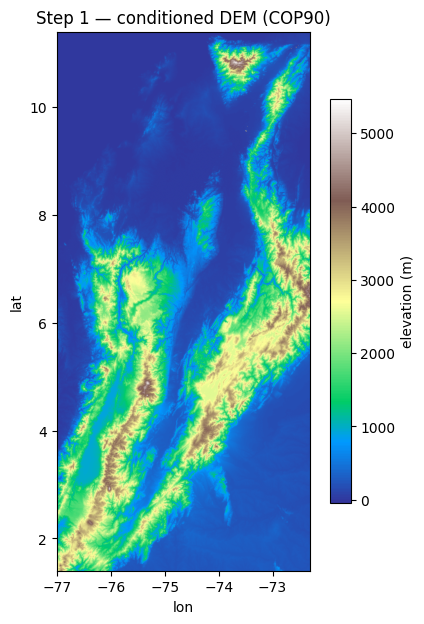

In [2]:
with rasterio.open(DEM) as ds:
    H, W = ds.height//SCALE, ds.width//SCALE          # <-- SCALE used here (down-sampling)
    elev = ds.read(1, out_shape=(H, W), resampling=Resampling.average).astype('float32')
    transform = ds.transform * Affine.scale(ds.width/W, ds.height/H)
    b = ds.bounds; extent = [b.left, b.right, b.bottom, b.top]

elev[elev < -50] = np.nan                              # mask ocean / DEM voids (below sea level)
flw = pyflwdir.from_dem(data=elev, nodata=np.nan, transform=transform, latlon=True)  # fills pits + D8
cell = ~np.isnan(elev)
print(f'grid {elev.shape}  (~{111/ (W/ (b.right-b.left)):.0f} m cells)  |  elevation {np.nanmin(elev):.0f}..{np.nanmax(elev):.0f} m')

fig, ax = plt.subplots(figsize=(5.2, 7))
im = ax.imshow(elev, extent=extent, cmap='terrain')
cb = plt.colorbar(im, ax=ax, shrink=.75); cb.set_label('elevation (m)')   # <-- legend
ax.set_title('Step 1 — conditioned DEM (COP90)'); ax.set_xlabel('lon'); ax.set_ylabel('lat'); plt.show()

## Step 2 — Drainage (upstream) area, and *why we show it on a log scale*

**What.** For every cell, the **upstream area** = how much land drains through it (km²). It grows from ~0 on ridges to
the whole basin at the outlet.

**Why log for the map.** Upstream area spans **6–7 orders of magnitude** (a few km² on tributaries vs ~258,000 km² on
the mainstem). On a *linear* colour scale only the mainstem would be visible and every tributary would look like 0.
A **log colour scale** compresses that range so the *whole* river network shows at once. The colour-bar below still
reads **real km²** — the log is only how the colours are spaced. (All thresholds later use the true km² values, not the log.)

upstream area ranges 0.54 .. 356,140 km2


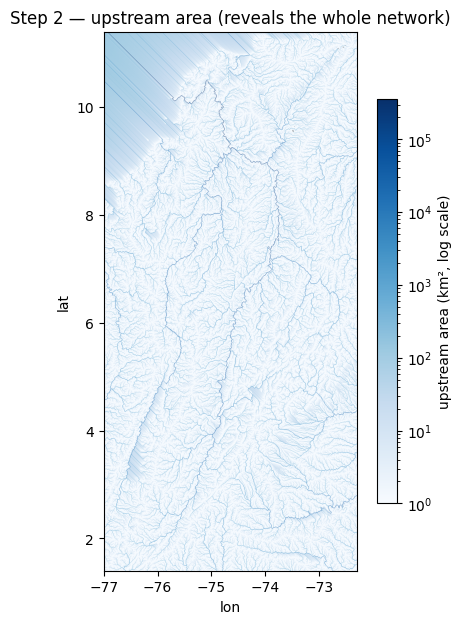

In [3]:
upa = flw.upstream_area(unit='km2')              # real drainage area in km^2 (used for thresholds)
print(f'upstream area ranges {np.nanmin(upa[cell]):.2f} .. {np.nanmax(upa):,.0f} km2')

fig, ax = plt.subplots(figsize=(5.2, 7))
im = ax.imshow(np.where(cell, upa, np.nan), extent=extent, cmap='Blues',
               norm=LogNorm(vmin=1, vmax=np.nanmax(upa)))          # log COLOURS, real km2 on the bar
cb = plt.colorbar(im, ax=ax, shrink=.75); cb.set_label('upstream area (km², log scale)')  # <-- legend
ax.set_title('Step 2 — upstream area (reveals the whole network)'); ax.set_xlabel('lon'); ax.set_ylabel('lat'); plt.show()

## Step 3 — The river network (apply the channel threshold)

**What.** A cell is a **river** once its upstream area exceeds `STREAM_THR`. Everything below is hillslope.

**Why a threshold.** Channels do not start at the ridge; they begin where enough water has collected. `STREAM_THR` sets
that "channel head". **Lower `STREAM_THR` → denser network** (more, smaller headwater streams); higher → sparser.

**Parameter used:** `STREAM_THR` (km²).\n\n*Display note:* rivers are drawn as **vector lines**, so they stay visible even at full 90 m — a 1-cell raster stream would disappear once the huge grid is shrunk into a small figure. Any straight parallel lines in the top-right (the sea) are flat-surface artifacts and are removed by the basin delineation in Step 4.

52,757 river cells with STREAM_THR = 100 km2


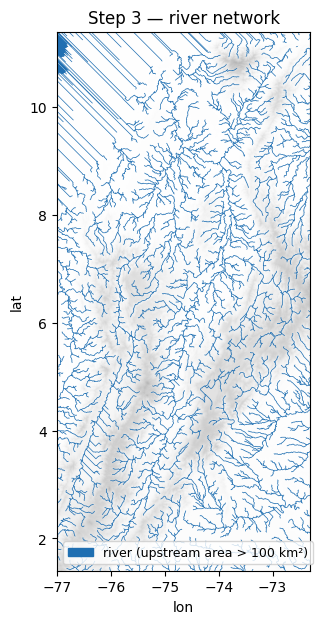

In [4]:
streams = upa > STREAM_THR                        # <-- STREAM_THR used here
print(f'{int(streams.sum()):,} river cells with STREAM_THR = {STREAM_THR} km2')

# rivers as VECTOR LINES -> stay visible at ANY resolution. A 1-cell-wide raster stream (90 m)
# vanishes when a 68M-cell grid is shrunk into a small figure -> this is why "no blue lines" appeared.
feats = flw.streams(mask=streams)
fig, ax = plt.subplots(figsize=(5.2, 7))
ax.imshow(np.where(cell, elev, np.nan), extent=extent, cmap='Greys', alpha=.30)   # faint relief backdrop
for ft in feats:
    xy = np.array(ft['geometry']['coordinates']); ax.plot(xy[:,0], xy[:,1], color='#1f6fb2', lw=0.5)
ax.legend(handles=[mpatches.Patch(color='#1f6fb2', label=f'river (upstream area > {STREAM_THR} km²)')], loc='lower left', fontsize=9)  # <-- legend
ax.set_title('Step 3 — river network'); ax.set_xlabel('lon'); ax.set_ylabel('lat'); plt.show()

## Step 4 — Delineate the basin from the outlet (Calamar)

**What.** We snap the outlet gauge **Calamar** onto the river and keep every cell that drains to it → the
Magdalena–Cauca basin. This also removes the ocean and any neighbouring basins in the box.

**Why from the outlet.** "The basin" is *by definition* everything that flows to its mouth. Delineating from Calamar
gives exactly that, and lets us **check the area against the known ~257,000 km²** — an independent quality control.

**Parameter used:** `OUTLET` (lon, lat of Calamar).

delineated basin area = 257,808 km2   (literature ~257,000  ->  QA OK)


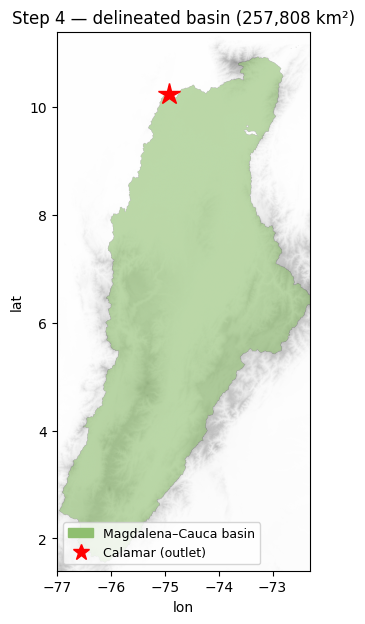

In [5]:
lon, lat = OUTLET
idxs, _ = flw.snap(xy=([lon], [lat]), mask=streams)   # snap gauge onto the river
basin_area = upa.flat[idxs[0]]                        # upstream area at the outlet = the basin area
basmask = flw.basins(idxs=idxs) > 0
print(f'delineated basin area = {basin_area:,.0f} km2   (literature ~257,000  ->  QA OK)')

fig, ax = plt.subplots(figsize=(5.2, 7))
ax.imshow(np.where(cell, elev, np.nan), extent=extent, cmap='Greys', alpha=.4)
ax.imshow(np.where(basmask, 1, np.nan), extent=extent, cmap=ListedColormap(['#8FbF6f']), alpha=.6)
ax.plot(lon, lat, marker='*', color='red', ms=16, linestyle='none')
ax.legend(handles=[mpatches.Patch(color='#8FbF6f', label='Magdalena–Cauca basin'),
                   plt.Line2D([],[],marker='*',color='red',ls='none',ms=12,label='Calamar (outlet)')],
          loc='lower left', fontsize=9)                                                    # <-- legend
ax.set_title(f'Step 4 — delineated basin ({basin_area:,.0f} km²)'); ax.set_xlabel('lon'); ax.set_ylabel('lat'); plt.show()

## Step 5 — Minibacias for a target count

**What.** We cut the basin into **minibacias** (unit-catchments) of roughly equal size. We pick the size so the count
matches `N_TARGET`:  **area_min = basin_area / N_TARGET**.

**Why area-based (not stream-order).** It gives a **directly controllable count** and uniform sizes. The count must be
large enough that **each of the 167 discharge gauges lands on its own minibacia** (so we can read simulated discharge
there) — a few thousand minibacias. `N_TARGET = 12000` → mean ≈ 21 km², a good detail/runtime compromise.

**Parameter used:** `N_TARGET`.  *Why the realised count is below `N_TARGET` (normal):* `subbasins_area` guarantees each minibacia is **≥ area_min**, but the number that actually fits depends on the river network — headwaters stay larger than area_min and a reach can't be split more finely than the network allows. So realised N < target N (~75 % at `SCALE=8`). The gap **shrinks at `SCALE=1`** (finer network → more split points). `N_TARGET` is a knob, not an exact count.

In [6]:
area_min = basin_area / N_TARGET                  # <-- N_TARGET used here (km2 per minibacia)
subs, mb_out = flw.subbasins_area(area_min)           # base partition (gauges are burned in Step 5b)
cell_km2 = abs(transform.a)*abs(transform.e)*(111.0**2)*np.cos(np.deg2rad((b.bottom+b.top)/2))
print(f'base minibacias inside basin: {int((np.bincount(np.where(basmask,subs,0).ravel())[1:] > 0).sum())}  (target {N_TARGET})')

base minibacias inside basin: 8550  (target 12000)


## Step 5b - Burn the gauges as pour points (local refinement)

We keep `N_TARGET` globally, but **force every discharge gauge to be a minibacia outlet**. Two benefits: (1) each gauge
sits *exactly* at a unit outlet, so simulated discharge is read at the right place; (2) any minibacia that held two
gauges is split **locally**, without inflating `N_TARGET` everywhere (separating near-duplicate gauges globally would
need N ~ 25-50k and slow the model). Standard MGB practice. Set `BURN_GAUGES=False` to skip.

burned 166 gauges as pour points
minibacias after refinement: 8672 | area mean 30 median 26 km2


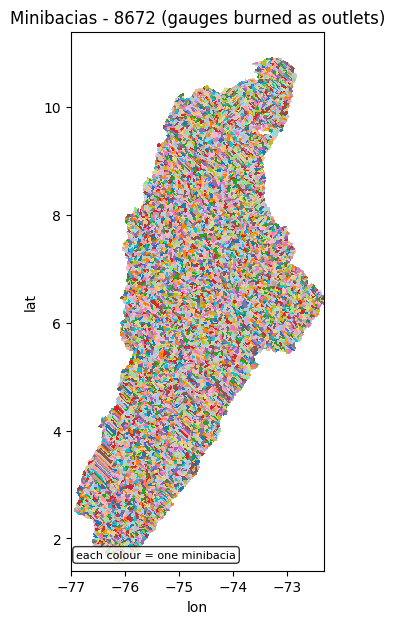

In [7]:
BURN_GAUGES = True
coords = REPO/'data'/'processed'/'stations_discharge_coords.csv'
gidx = None
if BURN_GAUGES and coords.exists():
    Gc = pd.read_csv(coords).dropna(subset=['lon','lat'])
    gidx,_ = flw.snap(xy=(Gc.lon.astype(float).values, Gc.lat.astype(float).values), mask=streams)
    mb_out = np.unique(np.concatenate([np.asarray(mb_out,dtype='int64'), np.asarray(gidx,dtype='int64')]))
    subs = flw.basins(idxs=mb_out)                     # re-partition: every gauge is now an outlet
    print(f'burned {len(Gc)} gauges as pour points')
subs = np.where(basmask, subs, 0)
counts = np.bincount(subs.ravel()); pres = counts[1:]>0; n_mini = int(pres.sum()); areas = counts[1:][pres]*cell_km2
print(f'minibacias after refinement: {n_mini} | area mean {areas.mean():.0f} median {np.median(areas):.0f} km2')
fig,ax = plt.subplots(figsize=(5.2,7))
ax.imshow(np.where(subs>0, subs%20, np.nan), extent=extent, cmap='tab20', interpolation='none')
ax.set_title(f'Minibacias - {n_mini} (gauges burned as outlets)'); ax.set_xlabel('lon'); ax.set_ylabel('lat')
ax.text(0.02,0.02,'each colour = one minibacia', transform=ax.transAxes, fontsize=8, va='bottom', bbox=dict(boxstyle='round',fc='white',alpha=.8))
plt.show()

## Step 6 — the QA that *justifies* `N_TARGET`: gauge separation

`N_TARGET = 12000` is only justified if **no two discharge gauges share a minibacia** (otherwise we cannot read a
distinct simulated discharge at each). We snap the 167 IDEAM stations onto the network and count collisions; if any,
raise `N_TARGET`. Station coordinates come from the IDEAM catalogue — build them once with
`python src/fetch_station_coords.py`. *(At the preview `SCALE=8` the coarse network misses small headwater gauges, so
many read as off-network; the test is definitive at `SCALE=1`.)*\n\n*Reading the result:* if `collisions > 0`, **raise `N_TARGET`** (and run at `SCALE=1`). A few residual collisions from **genuinely co-located stations** (same site) are acceptable — keep one per minibacia. **Off-network** gauges usually sit on small streams below `STREAM_THR` → lower it or run at `SCALE=1`.

In [8]:
coords = REPO/'data'/'processed'/'stations_discharge_coords.csv'
if coords.exists():
    G = pd.read_csv(coords).dropna(subset=['lon','lat'])
    G['lon']=G.lon.astype(float); G['lat']=G.lat.astype(float); G['code']=G.code.astype(str)
    gidx,_ = flw.snap(xy=(G.lon.values, G.lat.values), mask=streams)
    G['minibacia'] = subs.flat[gidx]
    on  = G[G.minibacia>0].copy(); off = int((G.minibacia<=0).sum())
    coll_ids = on.minibacia[on.minibacia.duplicated(keep=False)]
    coll = on[on.minibacia.isin(coll_ids)]
    def hav(a,b):                                  # km between (lon,lat) points
        la1,lo1,la2,lo2=map(np.radians,[a[1],a[0],b[1],b[0]])
        h=np.sin((la2-la1)/2)**2+np.cos(la1)*np.cos(la2)*np.sin((lo2-lo1)/2)**2
        return 6371*2*np.arcsin(np.sqrt(h))
    coloc=reso=0
    for mid,grp in coll.groupby('minibacia'):
        pts=grp[['lon','lat']].values
        dmax=max([hav(pts[i],pts[j]) for i in range(len(pts)) for j in range(i+1,len(pts))]+[0])
        coloc+=len(grp) if dmax<2 else 0; reso+=0 if dmax<2 else len(grp)
    # representative gauge per minibacia = the one with the most days of record
    meta=pd.read_csv(REPO/'data'/'processed'/'stations_discharge.csv')[['code','n_days']]; meta['code']=meta.code.astype(str)
    on=on.merge(meta,on='code',how='left'); on['n_days']=on.n_days.fillna(0)
    on['representative']=on.index.isin(on.groupby('minibacia')['n_days'].idxmax())
    on.to_csv(REPO/'data'/'processed'/'gauge_minibacia.csv',index=False)
    print(f'{len(G)} gauges | on-network {len(on)} | off-network {off}')
    print(f'collisions: {coll.minibacia.nunique()} minibacias hold >1 gauge ({len(coll)} gauges)')
    print(f'  -> co-located (<2 km, ACCEPTABLE): {coloc}   |   resolvable (raise N / refine): {reso}')
    print(f'representative gauges kept (1 per minibacia): {int(on.representative.sum())}  -> data/processed/gauge_minibacia.csv')
    print('  Verdict: all collisions are co-located stations -> keep N_TARGET.' if reso==0 else f'  {reso} residual collisions at this SCALE (same DEM cell); they resolve at SCALE=1. Gauge-burning already refines locally -> keep N_TARGET, do NOT inflate it.')
else:
    print('Station coordinates not found. Build them once:  python src/fetch_station_coords.py  (then re-run).')


166 gauges | on-network 159 | off-network 7
collisions: 6 minibacias hold >1 gauge (13 gauges)
  -> co-located (<2 km, ACCEPTABLE): 10   |   resolvable (raise N / refine): 3
representative gauges kept (1 per minibacia): 152  -> data/processed/gauge_minibacia.csv
  3 residual collisions at this SCALE (same DEM cell); they resolve at SCALE=1. Gauge-burning already refines locally -> keep N_TARGET, do NOT inflate it.


## Step 7 — Export the results (so notebook 08 just loads them)

We save the preprocessing products to `data/processed/` so the next notebooks **do not re-run the delineation**:
`minibacias.tif` (the minibacia grid), `minibacias.csv` (id, area, downstream link = the routing topology), and
`gauge_minibacia.csv` (Step 6).

In [9]:
proc = REPO/'data'/'processed'; proc.mkdir(parents=True, exist_ok=True)
# --- minibacia table with downstream topology ---
ids_ds = flw.idxs_ds; subsf = subs.ravel()
cell_km2 = abs(transform.a)*abs(transform.e)*(111.0**2)*np.cos(np.deg2rad((b.bottom+b.top)/2))
rows=[]
for oidx in mb_out:
    oidx=int(oidx); mid=int(subsf[oidx])
    if mid==0: continue
    dcell=int(ids_ds[oidx]); dmid=int(subsf[dcell])
    if dcell==oidx or dmid==mid or dmid==0: dmid=-1          # basin outlet / terminal
    rows.append((mid,dmid))
mtab=pd.DataFrame(rows,columns=['id','downstream']).drop_duplicates('id')
areas=pd.Series(subs[subs>0].ravel()).value_counts()*cell_km2
mtab['area_km2']=mtab.id.map(areas).round(2)
mtab=mtab[['id','area_km2','downstream']].sort_values('id')
mtab.to_csv(proc/'minibacias.csv', index=False)
# --- minibacia raster (int32, id per cell, nodata 0) ---
prof=dict(driver='GTiff',height=H,width=W,count=1,dtype='int32',crs='EPSG:4326',transform=transform,nodata=0,compress='lzw')
import tempfile, shutil
_t=str(Path(tempfile.gettempdir())/'minibacias_tmp.tif')
with rasterio.open(_t,'w',**prof) as dst: dst.write(subs.astype('int32'),1)
shutil.copyfile(_t, str(proc/'minibacias.tif'))
print(f'exported -> data/processed/minibacias.tif ({H}x{W})  and  minibacias.csv ({len(mtab)} minibacias: id, area_km2, downstream)')


exported -> data/processed/minibacias.tif (1500x705)  and  minibacias.csv (8672 minibacias: id, area_km2, downstream)


## Quality control & next step

**Checks done here:**
- Basin area ≈ 257,000 km² (Step 4) — the delineation is correct.
- Minibacia count ≈ `N_TARGET`, with a sensible mean area (Step 5).

**Check still to do (before the model):** confirm **each of the 167 discharge stations falls on a distinct minibacia**
(if two share one, raise `N_TARGET` or refine locally).

**Next (Phase A, part 2 — notebook 08):** build the **URH** = overlay reclassified land cover × soil groups inside each
minibacia (area-weighted fractions), and export the **minibacia table** (id, area, downstream link, slope). Then
**Phase B:** the MGB-SA water balance → discharge, calibrated on the IDEAM stations.